## (a) Porcentaje de valores nulos

En esta sección se calcula el porcentaje de valores nulos por columna.  
Esto permite identificar variables que requieren imputación o eliminación antes del análisis.


In [19]:
import pandas as pd

# Cargar dataset
df = pd.read_csv("../data/video_game_reviews.csv")

# Porcentaje de nulos por columna
null_percent = df.isnull().mean() * 100
display(null_percent.sort_values(ascending=False))


Game Title                 0.0
User Rating                0.0
Age Group Targeted         0.0
Price                      0.0
Platform                   0.0
Requires Special Device    0.0
Developer                  0.0
Publisher                  0.0
Release Year               0.0
Genre                      0.0
Multiplayer                0.0
Game Length (Hours)        0.0
Graphics Quality           0.0
Soundtrack Quality         0.0
Story Quality              0.0
User Review Text           0.0
Game Mode                  0.0
Min Number of Players      0.0
dtype: float64

## (b) Porcentaje de ceros en variables numéricas

Se calcula el porcentaje de valores iguales a cero en las variables numéricas.  
Esto permite evaluar si los ceros representan valores válidos o posibles datos faltantes.


In [20]:
# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include='number')

# Calcular porcentaje de ceros en cada columna numérica
zero_percent = (numeric_cols == 0).mean() * 100
display(zero_percent.sort_values(ascending=False))

User Rating              0.0
Price                    0.0
Release Year             0.0
Game Length (Hours)      0.0
Min Number of Players    0.0
dtype: float64

## (c) Gráficos de las variables

Se generan visualizaciones estéticas para analizar la distribución y relación entre variables.  
- Histogramas para variables numéricas.  
- Gráficos de barras para variables categóricas.  
- Mapa de correlación para variables numéricas.


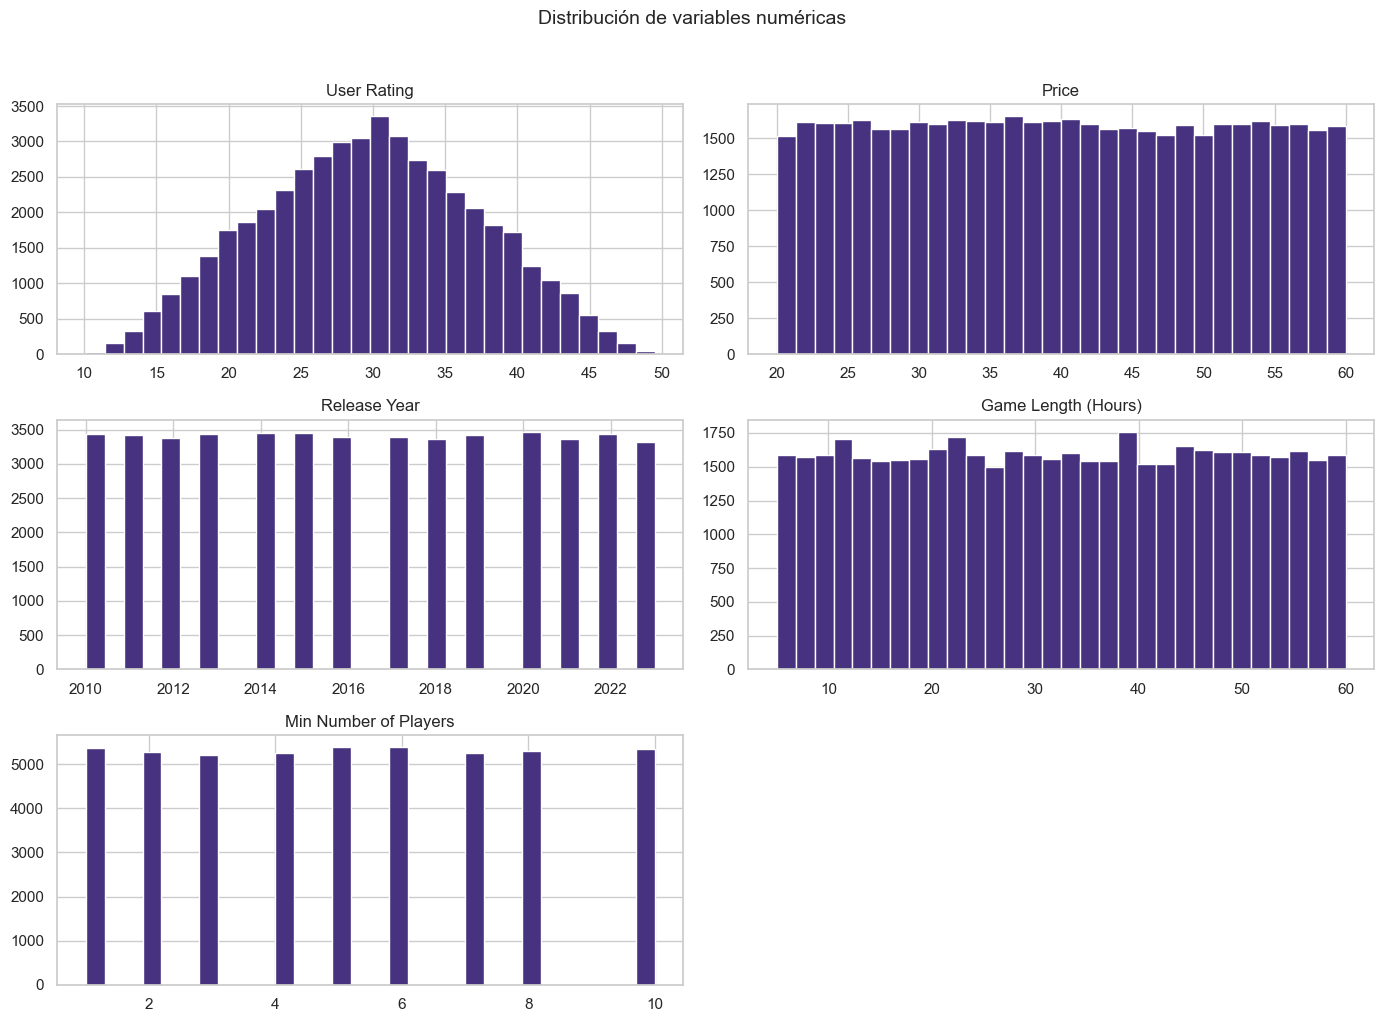

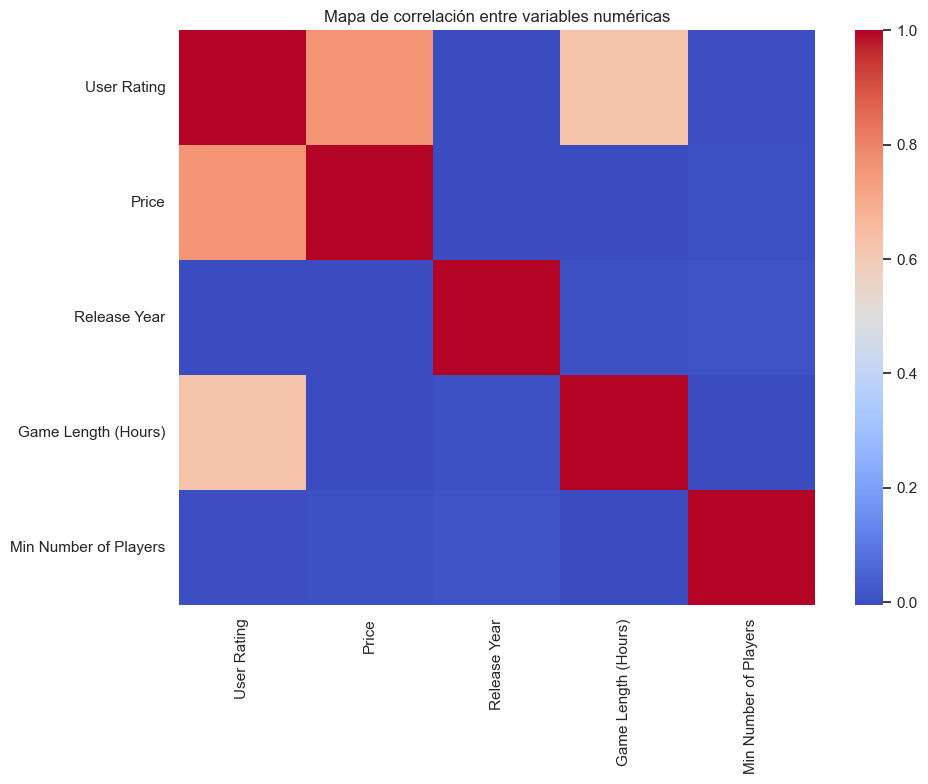

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selección de columnas numéricas
numeric_cols = df.select_dtypes(include='number')

# Histogramas de variables numéricas
numeric_cols.hist(figsize=(14, 10), bins=30)
plt.suptitle("Distribución de variables numéricas", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Mapa de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=False, cmap="coolwarm")
plt.title("Mapa de correlación entre variables numéricas")
plt.tight_layout()
plt.show()


## (d) Visualización de la variable de salida

La variable objetivo es `User Rating`.  
Se analiza su distribución para identificar sesgos, valores atípicos o concentraciones que puedan afectar los modelos predictivos.


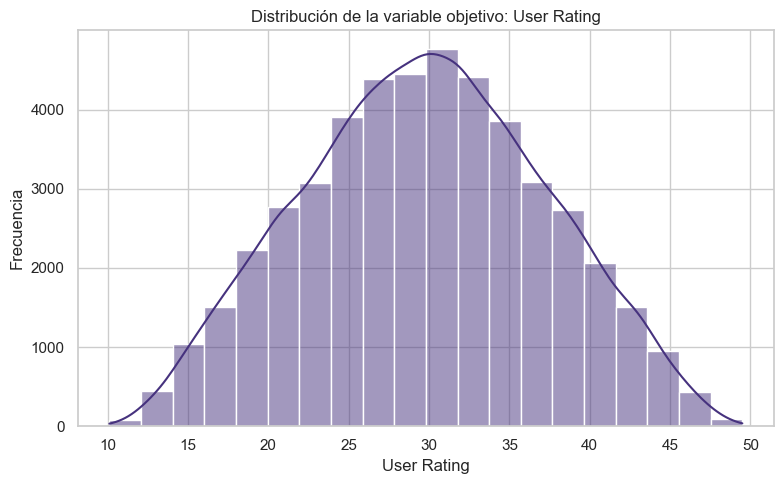

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribución de la variable de salida
plt.figure(figsize=(8, 5))
sns.histplot(df['User Rating'], bins=20, kde=True)
plt.title("Distribución de la variable objetivo: User Rating")
plt.xlabel("User Rating")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## (e) Eliminación de registros con nulos, ceros o inconsistencias

Se eliminan registros con valores nulos o inconsistentes en variables relevantes.  
- Los nulos pueden distorsionar análisis estadísticos y modelos predictivos.  
- Los ceros en variables numéricas se eliminan solo si no representan valores válidos.  
Se justifica esta limpieza para mantener coherencia y calidad en los datos.


In [23]:
# Copia del dataset original
df_clean = df.copy()

# Eliminar filas con valores nulos
df_clean = df_clean.dropna()

# Identificar columnas numéricas
numeric_cols = df_clean.select_dtypes(include='number').columns

# Eliminar filas con ceros en columnas numéricas (si los ceros no tienen sentido)
for col in numeric_cols:
    if (df_clean[col] == 0).sum() > 0:
        df_clean = df_clean[df_clean[col] != 0]

# Reiniciar índices
df_clean.reset_index(drop=True, inplace=True)

# Mostrar resultado
print("Dimensiones después de limpieza:", df_clean.shape)


Dimensiones después de limpieza: (47774, 18)


## (f) Eliminación de características no aplicables

Se eliminan variables que no aportan información útil para el modelo predictivo.  
Los criterios utilizados son:
- Varianza nula o muy baja.
- Columnas con un solo valor único (sin variabilidad).
- Identificadores o variables que no influyen en la predicción.
Esto reduce la dimensionalidad y mejora la eficiencia del análisis.


In [24]:
from sklearn.feature_selection import VarianceThreshold

# Copia del dataset limpio
df_features = df_clean.copy()

# Eliminar columnas con un solo valor único
unique_cols = [col for col in df_features.columns if df_features[col].nunique() == 1]
df_features.drop(columns=unique_cols, inplace=True)

# Aplicar filtro de baja varianza (umbral = 0.01)
numeric_data = df_features.select_dtypes(include='number')
selector = VarianceThreshold(threshold=0.01)
selector.fit(numeric_data)

low_variance_cols = numeric_data.columns[~selector.get_support()]
df_features.drop(columns=low_variance_cols, inplace=True)

# Mostrar columnas eliminadas
print("Columnas eliminadas por valor único:", unique_cols)
print("Columnas eliminadas por baja varianza:", list(low_variance_cols))
print("Dimensiones finales del dataset:", df_features.shape)

Columnas eliminadas por valor único: []
Columnas eliminadas por baja varianza: []
Dimensiones finales del dataset: (47774, 18)


## (g) Tratamiento de outliers y varianza extrema

Se identifican y eliminan valores atípicos (outliers) mediante el rango intercuartílico (IQR).  
Este método considera como outliers los valores que están fuera del rango:
\[ Q1 - 1.5 \times IQR, \, Q3 + 1.5 \times IQR \]
La eliminación de estos valores evita que afecten la media, desviación estándar y la calidad del modelo.


In [25]:
import numpy as np

# Copia del dataset con características filtradas
df_no_outliers = df_features.copy()

# Detección y eliminación de outliers por IQR
numeric_cols = df_no_outliers.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_no_outliers = df_no_outliers[
        (df_no_outliers[col] >= lower_bound) & (df_no_outliers[col] <= upper_bound)
    ]

# Reiniciar índices
df_no_outliers.reset_index(drop=True, inplace=True)

print("Dimensiones después de eliminar outliers:", df_no_outliers.shape)


Dimensiones después de eliminar outliers: (47774, 18)


## (h) Correlación y eliminación de variables redundantes

Se analiza la correlación entre variables numéricas mediante un mapa de calor.  
Las variables con correlación alta (|r| > 0.9) se eliminan para evitar multicolinealidad, ya que aportan información redundante al modelo.


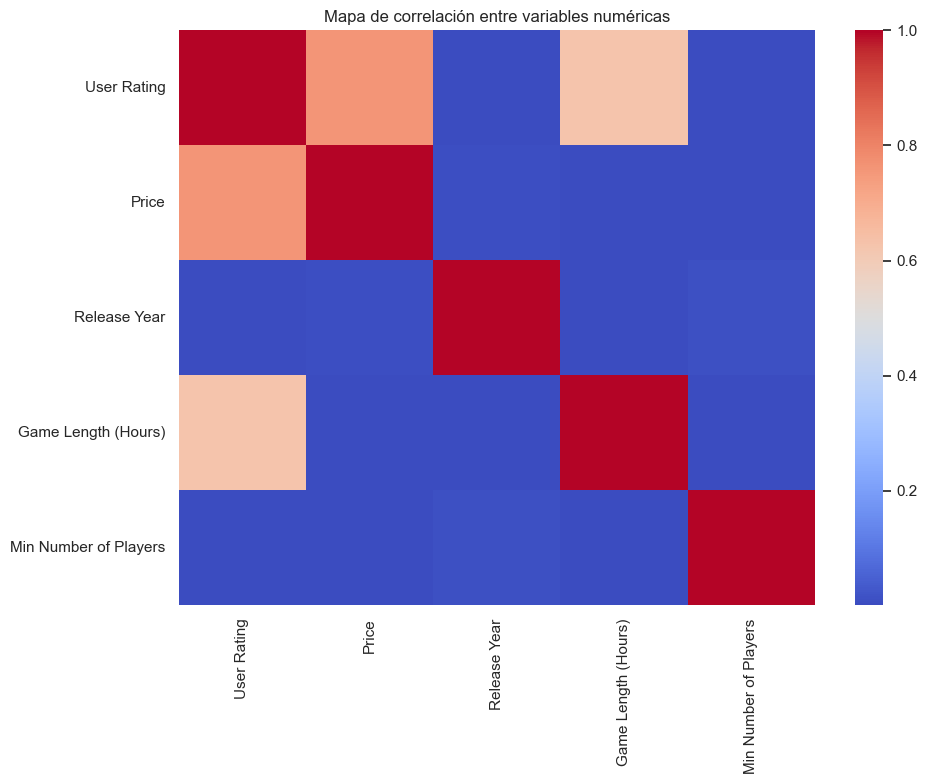

Columnas eliminadas por alta correlación: []
Dimensiones finales del dataset: (47774, 18)


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de correlación
corr_matrix = df_no_outliers.select_dtypes(include='number').corr().abs()

# Visualizar el mapa de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Mapa de correlación entre variables numéricas")
plt.tight_layout()
plt.show()

# Identificar pares de variables altamente correlacionadas
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [column for column in upper.columns if any(upper[column] > 0.9)]

# Eliminar variables redundantes
df_final = df_no_outliers.drop(columns=high_corr)

print("Columnas eliminadas por alta correlación:", high_corr)
print("Dimensiones finales del dataset:", df_final.shape)


## (i) Clustering con K-Means y análisis de grupos

Se aplica el algoritmo K-Means para agrupar los registros en grupos homogéneos.  
1. Se normalizan las variables numéricas.  
2. Se determina el número óptimo de clusters mediante el método del codo y el coeficiente de silueta.  
3. Se entrena el modelo de K-Means y se describe brevemente cada cluster.

Esto permite identificar patrones o segmentos dentro del conjunto de datos.


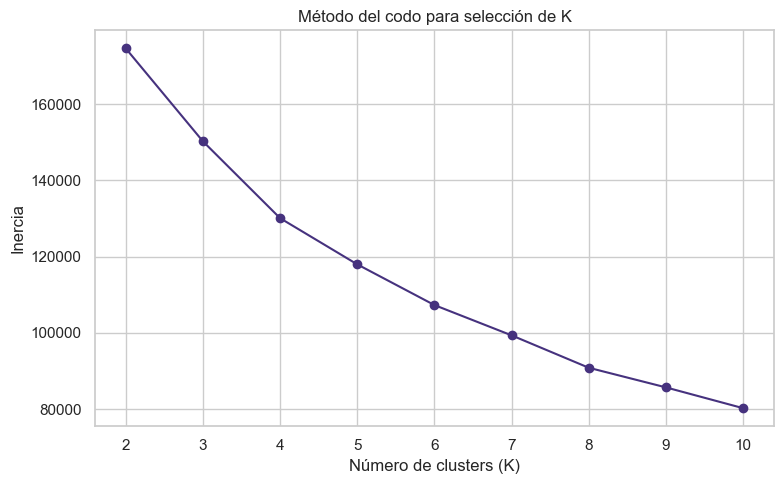

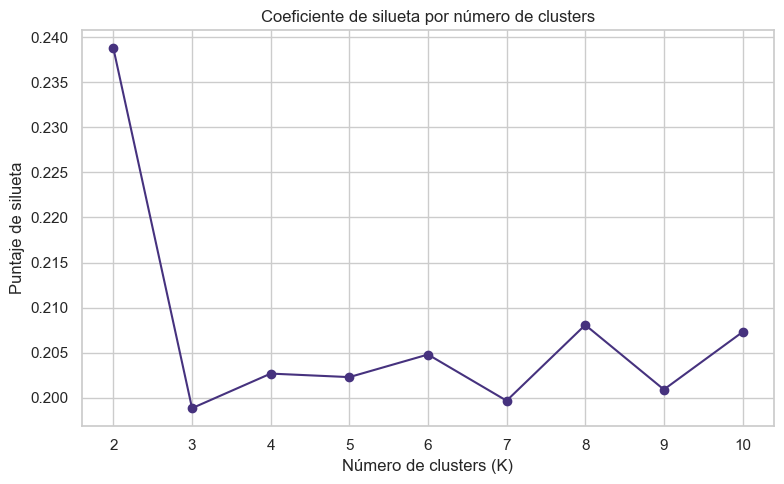

Número óptimo de clusters según silueta: 2
Cluster
0    23805
1    23969
Name: count, dtype: int64

Descripción promedio de cada cluster:
<bound method DataFrame.round of          User Rating      Price  Release Year  Game Length (Hours)  \
Cluster                                                              
0          23.579311  31.454223   2016.516572            26.372329   
1          35.817335  48.390380   2016.445576            38.549214   

         Min Number of Players  
Cluster                         
0                     5.129133  
1                     5.104468  >


In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Selección de variables numéricas
X = df_final.select_dtypes(include='number')

# Normalización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determinar número óptimo de clusters (método del codo)
inertia = []
range_clusters = range(2, 11)
for k in range_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range_clusters, inertia, marker='o')
plt.title("Método del codo para selección de K")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.tight_layout()
plt.show()

# Calcular silueta para confirmar mejor K
silhouette_scores = []
for k in range_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(range_clusters, silhouette_scores, marker='o')
plt.title("Coeficiente de silueta por número de clusters")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Puntaje de silueta")
plt.tight_layout()
plt.show()

# Entrenamiento final con el mejor número de clusters
best_k = range_clusters[silhouette_scores.index(max(silhouette_scores))]
kmeans_final = KMeans(n_clusters=best_k, random_state=42)
df_final['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"Número óptimo de clusters según silueta: {best_k}")
print(df_final['Cluster'].value_counts().sort_index())

# Descripción rápida de cada cluster
cluster_summary = df_final.groupby('Cluster').mean(numeric_only=True).round
print("\nDescripción promedio de cada cluster:")
print(cluster_summary)